Каждый из нас писал в школе и университете изложения, сочинения, рефераты. А значит, в каждом из нас живет великий русский писатель.
В этой работе будем раскрывать свои таланты, находить себя в ряду таких гениев, как Пушкин, Гоголь, Грибоедов

В этой работе
- скачаем корпус текстов 20-ми русских писателей. Каждый текст разобьем на обучающую и тестовую выборки.
- разработаем и обучим нейронную сеть определяющию авторство фрагментов текста (по тестовой выборке)
- скачаем СВОЕ сочинение (или чье-нибудь - есть в архиве). Сделаем из него проверочную выборку
- предложим нейронке предсказать автора сочинения (по проверочной выборке)
- объявим себя великим писателем, например, Гончаровым

Ссылка на архив: https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip

В работе рекомендуется пользоваться материалами из ноутбука практического занятия "Рекуррентные и одномерные сверточные нейронные сети". Допускается выбрать лучший вариант нейронки и адаптировать ее структуру, параметры обучения и формирования датасетов под свои *нужды*

In [1]:
# ваше решение
import gdown
import os
import re
import numpy as np
import pandas as pd
import requests
import zipfile
import io

In [2]:
url = "https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip"

r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("writers")

In [3]:
print(os.listdir("writers"))

['Пастернак.txt', 'Шолохов.txt', 'Чехов.txt', 'Носов.txt', 'Тургенев.txt', 'Толстой.txt', 'Гончаров.txt', 'Достоевский.txt', 'Грибоедов.txt', 'Лермонтов.txt', 'Лесков.txt', 'Гоголь.txt', 'Булгаков.txt', 'Горький.txt', 'Пушкин.txt', 'Васильев.txt', 'Беляев.txt', 'Куприн.txt', 'Каверин.txt', 'Катаев.txt']


In [4]:
texts = []
authors = []

# Папка с текстами разных авторов
data_dir = "writers"

# Проходим по всем файлам в директории
for fname in os.listdir(data_dir):
    file_path = os.path.join(data_dir, fname)

    # Пропускаем всё, что не является файлом (например, папки)
    if not os.path.isfile(file_path):
        continue

    # Извлекаем имя автора из названия файла
    # Например: "pushkin.txt" → "pushkin"
    author = fname.replace(".txt", "")

    # Читаем весь текст файла
    with open(file_path, encoding='utf-8') as f:
        text = f.read()

    # Добавляем текст в список текстов
    texts.append(text)

    # Добавляем соответствующего автора в список меток
    authors.append(author)

In [5]:
# Разбиение длинного текста на перекрывающиеся фрагменты (чанки)
def split_text(text, chunk_size=1000, step=500):
    chunks = []

    # Идём по тексту с шагом step
    # каждый раз берём кусок длиной chunk_size
    for i in range(0, len(text) - chunk_size, step):
        chunks.append(text[i:i+chunk_size])

    return chunks

X = []
y = []

# Проходим по каждому тексту и соответствующему автору
for text, author in zip(texts, authors):

    # Разбиваем текст на чанки фиксированной длины
    chunks = split_text(text)

    # Добавляем все чанки в общий список признаков
    X.extend(chunks)

    # Каждому чанку присваиваем метку автора
    # (один и тот же автор для всех фрагментов текста)
    y.extend([author] * len(chunks))

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 15000
MAX_LEN = 800

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<UNK>")
tokenizer.fit_on_texts(X)
# Преобразование текста в числовые последовательности
X = tokenizer.texts_to_sequences(X)
# Приведение всех последовательностей к одной длине MAX_LEN
X = pad_sequences(X, maxlen=MAX_LEN)

In [7]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [9]:
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.models import Sequential

model = Sequential([
    Embedding(VOCAB_SIZE, 64),

    Conv1D(128, kernel_size=5, activation='relu'),

    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(len(le.classes_), activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=7,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/7
1405/1405 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.4388 - loss: 1.8326 - val_accuracy: 0.7748 - val_loss: 0.8030
Epoch 2/7
1405/1405 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.7701 - loss: 0.7740 - val_accuracy: 0.8605 - val_loss: 0.4675
Epoch 3/7
1405/1405 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8497 - loss: 0.4831 - val_accuracy: 0.8842 - val_loss: 0.3720
Epoch 4/7
1405/1405 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8953 - loss: 0.3280 - val_accuracy: 0.8962 - val_loss: 0.3460
Epoch 5/7
1405/1405 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9193 - loss: 0.2432 - val_accuracy: 0.9060 - val_loss: 0.3321
Epoch 6/7
1405/1405 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9357 - loss: 0.1908 - val_accuracy: 0.9088 - val_loss: 0.3333
Epoch 7/7
1405/1405 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9427 - loss: 0.1668 - val_accuracy: 0.9092 - val_loss: 0.3610


In [11]:
import matplotlib.pyplot as plt

def plot_history(history, title="Обучение модели"):

    # Accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title + " — Accuracy")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(title + " — Loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

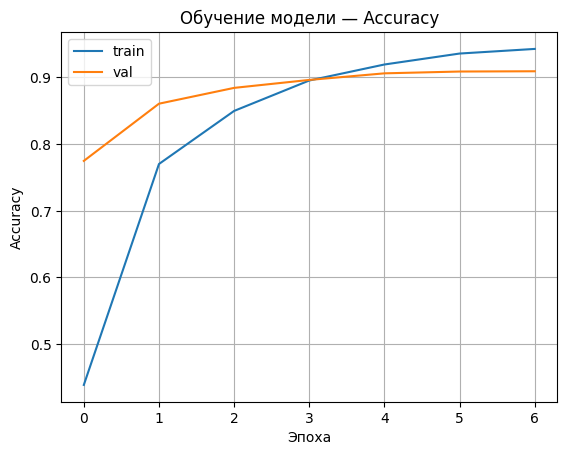

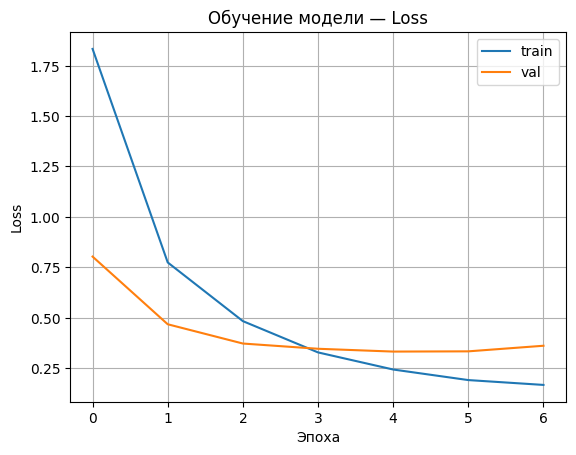

In [12]:
plot_history(history)

In [13]:
my_text = """
Вечер медленно опускался на уездный город, и в этом тихом угасании дня было что-то необыкновенно умиротворяющее. Улицы пустели, редкие прохожие спешили по своим делам, а в окнах домов загорались огни, придавая всему окружающему особую теплоту. Ветер, мягко проходящий между домами, едва колыхал занавески и приносил с собой запах сырой земли и дыма.

Иван Петрович стоял у окна и задумчиво смотрел вдаль. Мысли его были смутны и беспорядочны, как это часто бывает у человека, который слишком долго откладывал важное решение. Он чувствовал, что дальше так продолжаться не может, но и решиться на перемены не находил в себе сил. В памяти всплывали отдельные эпизоды прожитых лет — неяркие, но почему-то болезненно значимые.

В этой внутренней борьбе отражалась вся его жизнь — тихая, размеренная, но лишенная подлинного смысла. И лишь теперь, когда время, казалось, начинало ускользать, он впервые ясно осознал это. Ему казалось, что он слишком долго жил по инерции, не задавая себе главных вопросов и довольствуясь тем, что есть.

Он тяжело вздохнул и отошел от окна, словно пытаясь уйти от самого себя, но понимал, что сделать это невозможно. В комнате было тихо, и эта тишина давила сильнее любых слов. Где-то вдалеке пробили часы, отмеряя еще один уходящий час его жизни.
"""

In [14]:

chunks = split_text(my_text)

seq = tokenizer.texts_to_sequences(chunks)
pad = pad_sequences(seq, maxlen=MAX_LEN)

pred = model.predict(pad)
avg_pred = pred.mean(axis=0)

author_idx = avg_pred.argmax()
print("Предсказанный автор:", le.classes_[author_idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
Предсказанный автор: Тургенев
